# Calculate $\gamma_{thermal}$ and $\gamma_{spatial}$

This shows how the thermal and spatial baseline contributions to coherence are calculated, then divided out of the NISAR coherence to leave $\gamma_{temporal}$. 

In [2]:
import numpy as np
import xarray as xr
import rioxarray  # noqa: F401
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
from seaborn import set_theme
set_theme()

import sys
import os
from pathlib import Path

# import from this repo 
project_root = str(Path(os.getcwd()).parent)
if project_root not in sys.path:
    sys.path.append(project_root)

%load_ext autoreload
%autoreload 2
from scripts.download import build_snr_timeseries, interpolate_radar_grid_to_dem
from scripts.coherence import thermal_coherence, spatial_coherence

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


First, we setup logging to get useful information and error messages. 

In [3]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    force=True 
)

Open the data cubes that were saved by the download notebook. 

In [4]:
data_dir = "../data/"

nisar_20m = xr.open_zarr(data_dir + 'nisar/zarrs/obs_20m.zarr')
nisar_80m = xr.open_zarr(data_dir + 'nisar/zarrs/obs_80m.zarr')

Next, load the ASO snow depth and use its footprint to mask the cubes. 

In [5]:
aso = xr.open_dataarray(data_dir + 'aso/er_20260318/ASO_EastRiver_2026Mar18_snowdepth_3m.tif')

nisar_80m = nisar_80m.where(aso.rio.reproject_match(nisar_80m).notnull())
nisar_20m = nisar_20m.where(aso.rio.reproject_match(nisar_20m).notnull())

The start and end time of each date pair are stored in the cube. 

In [6]:
starts = nisar_80m['start'].values
ends = nisar_80m['end'].values

## $\gamma_{thermal}$

Thermal noise coherence depends on the SNR of the two acquisitions in each pair. We get the SNR from the backscatter and NEBZ files. 

In [7]:
bs_files = [item.resolve() for item in Path(data_dir + 'nisar/east_river/').rglob('*backscatter*')]
nebz_files = [item.resolve() for item in Path(data_dir + 'nisar/east_river/').rglob('*NEBZ*')]

Build a time series of SNR from the files. The time zone offset needs to match the cubes. 

In [8]:
snr = build_snr_timeseries(bs_files, nebz_files, utc_offset_hours=-7)

Resample the SNR to 20 m and mask it to the ASO footprint. 

In [9]:
res = 20

snr_dwn = snr.rio.reproject(
    snr.rio.crs,
    resolution=res
)
snr_dwn = snr_dwn.where(aso.rio.reproject_match(snr_dwn).notnull())

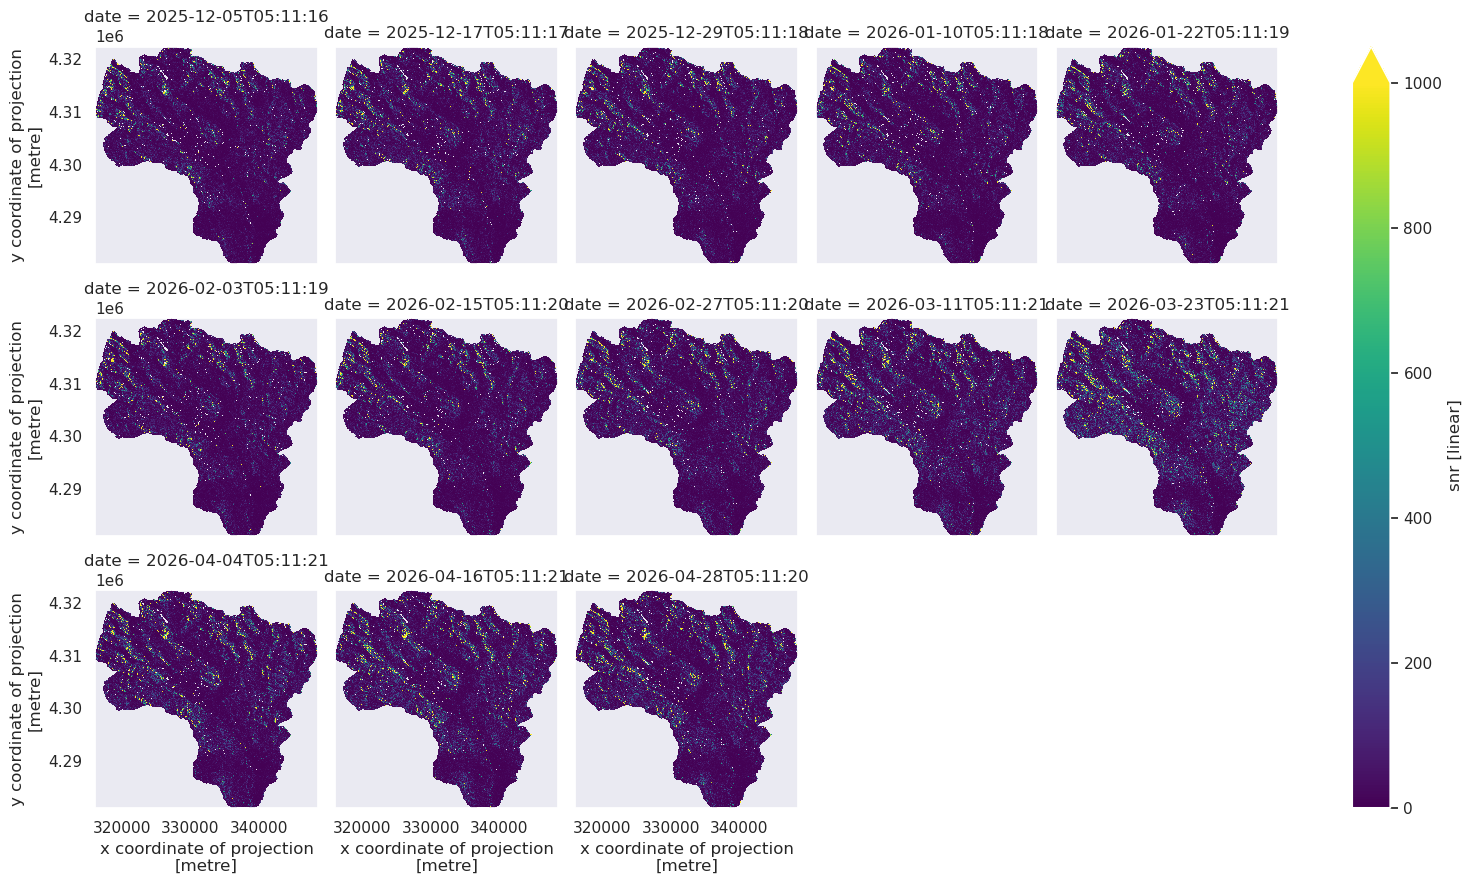

In [10]:
snr_dwn.plot(col='date', col_wrap=5, vmin=0, vmax=1000)

Calculate $\gamma_{thermal}$ for every date pair, then plot it. 

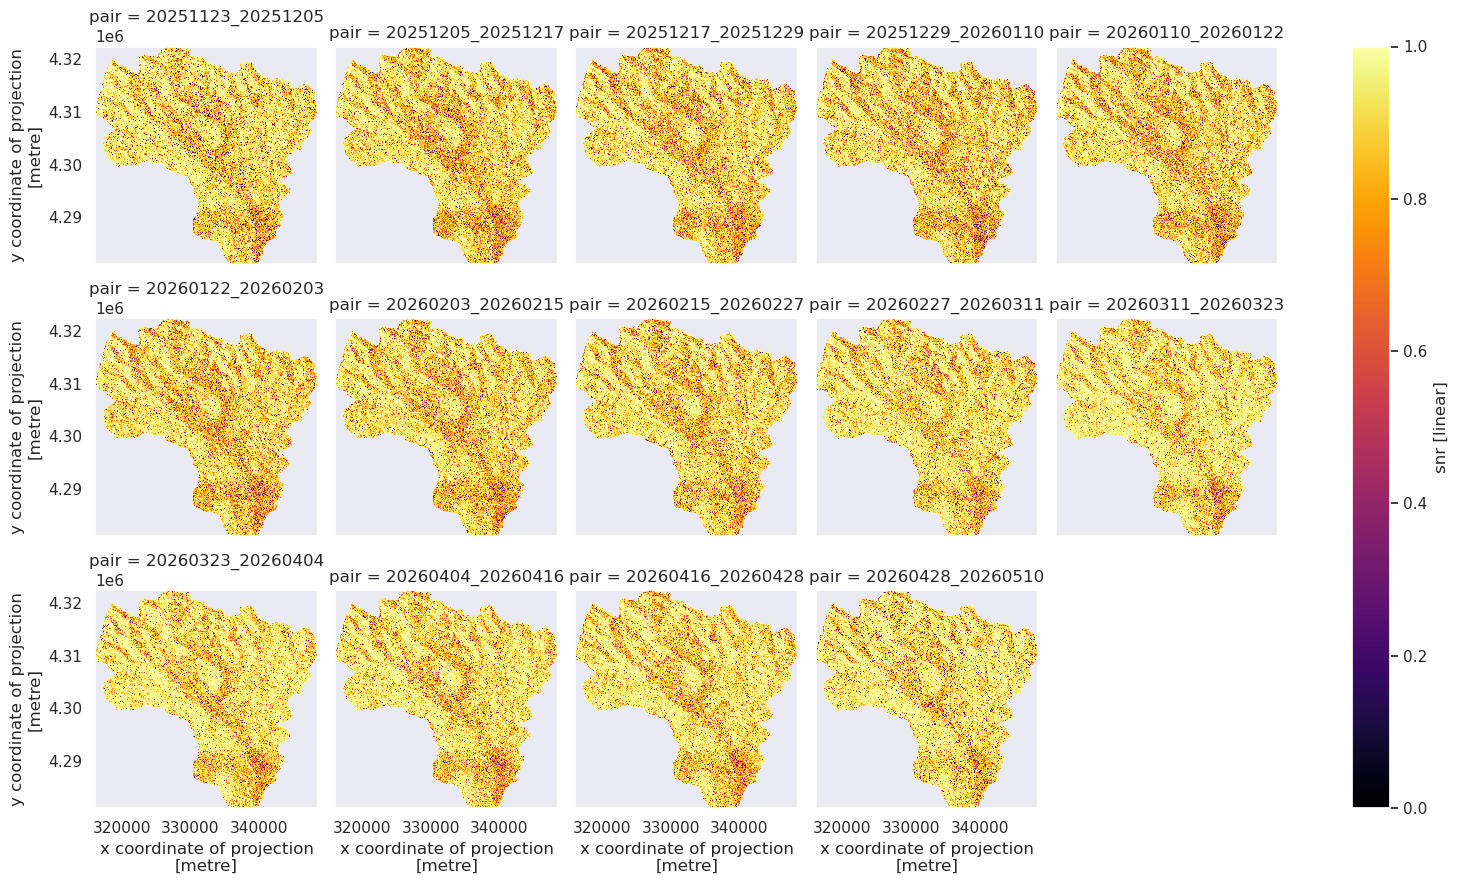

In [29]:
gamma_thermal = thermal_coherence(snr_dwn, starts, ends).squeeze()
gamma_thermal = gamma_thermal.rio.write_crs(snr.rio.crs)

gamma_thermal.plot(col='pair', col_wrap=5, vmin=0, vmax=1, cmap='inferno')

## $\gamma_{spatial}$

Spatial baseline coherence depends on the perpendicular baseline, incidence angle and slant range. These are interpolated onto the DEM. 

In [23]:
inc_files = [item.resolve() for item in Path(data_dir + 'nisar/east_river/').rglob('*incidence_angle*')]
bl_files = [item.resolve() for item in Path(data_dir + 'nisar/east_river/').rglob('*perpendicular_baseline*')]
r_files = [item.resolve() for item in Path(data_dir + 'nisar/east_river/').rglob('*reference_slant_range*')]

Interpolate each radar grid layer onto the 80 m DEM. 

In [24]:
baselines = interpolate_radar_grid_to_dem(nisar_80m['elevation'], bl_files, utc_offset_hours=-7)
thetas = interpolate_radar_grid_to_dem(nisar_80m['elevation'], inc_files, utc_offset_hours=-7)
rs = interpolate_radar_grid_to_dem(nisar_80m['elevation'], r_files, utc_offset_hours=-7)

Calculate $\gamma_{spatial}$, then plot it. 

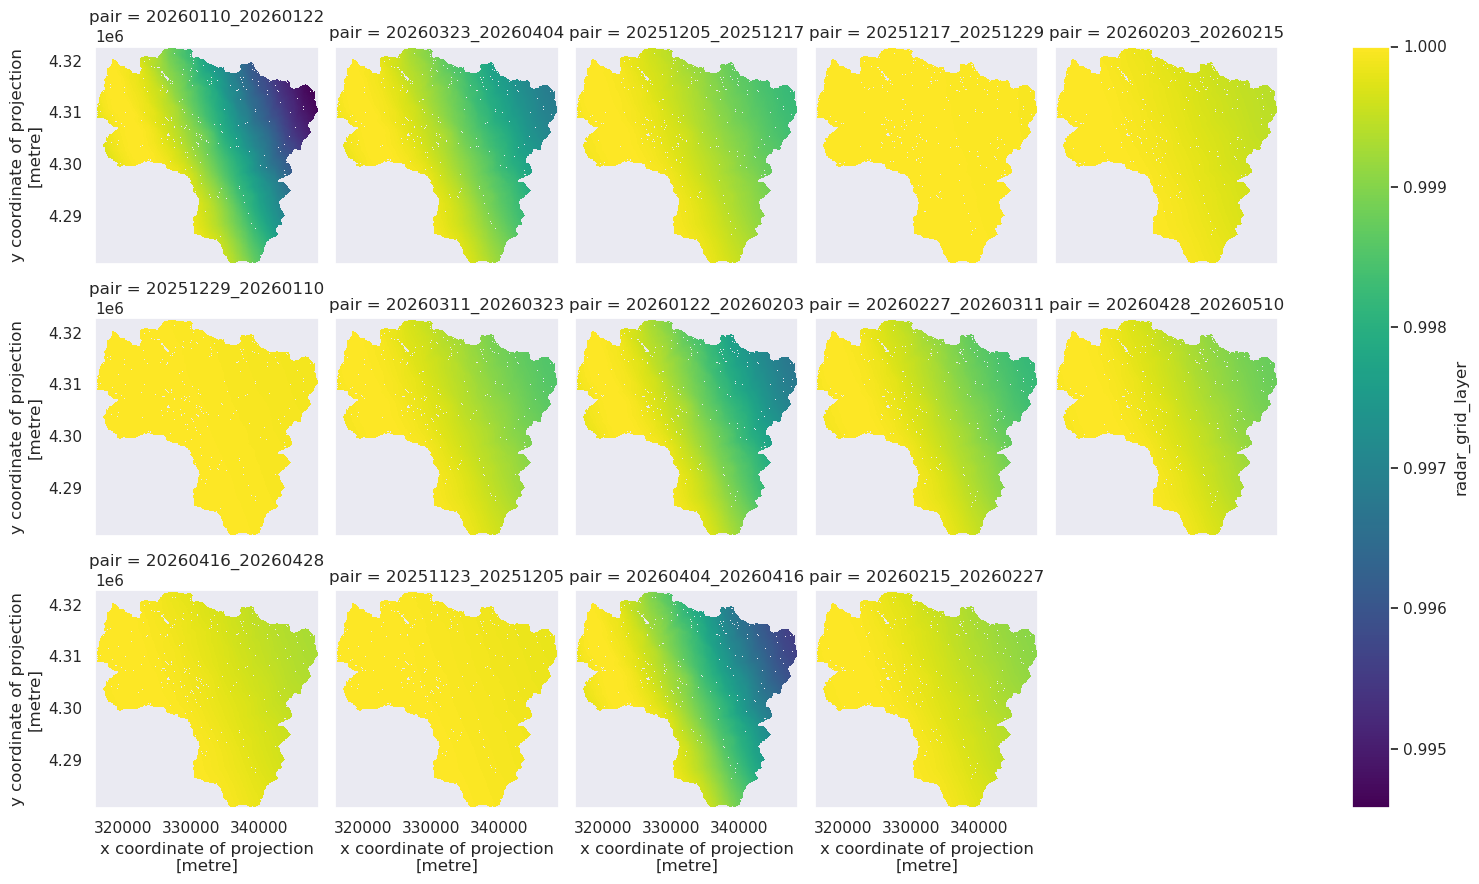

In [30]:
res = 3 
wvl = .24
gamma_spatial = spatial_coherence(baselines, thetas, rs, res, wvl).squeeze()

gamma_spatial.plot(col='pair', col_wrap=5)

## $\gamma_{temporal}$

Dividing the coherence by $\gamma_{thermal}$ and $\gamma_{spatial}$ leaves $\gamma_{temporal}$. 

In [36]:
nisar_80m['gamma_temporal'] = gamma_thermal.rio.reproject_match(nisar_80m, resampling=Resampling.bilinear) 
nisar_80m['gamma_spatial'] = gamma_spatial.rio.reproject_match(nisar_80m, resampling=Resampling.bilinear)


In [37]:
nisar_20m['gamma_temporal'] = gamma_thermal.rio.reproject_match(nisar_20m, resampling=Resampling.bilinear) 
nisar_20m['gamma_spatial'] = gamma_spatial.rio.reproject_match(nisar_20m, resampling=Resampling.bilinear)


In [31]:
nisar_80m['gamma_temporal'] = nisar_80m['coherence'] / (gamma_thermal.rio.reproject_match(nisar_80m, resampling=Resampling.bilinear) * gamma_spatial.rio.reproject_match(nisar_80m, resampling=Resampling.bilinear))
nisar_20m['gamma_temporal'] = nisar_20m['coherence'] / (gamma_thermal.rio.reproject_match(nisar_20m, resampling=Resampling.bilinear) * gamma_spatial.rio.reproject_match(nisar_20m, resampling=Resampling.bilinear))

Plot $\gamma_{temporal}$ for both grids. 

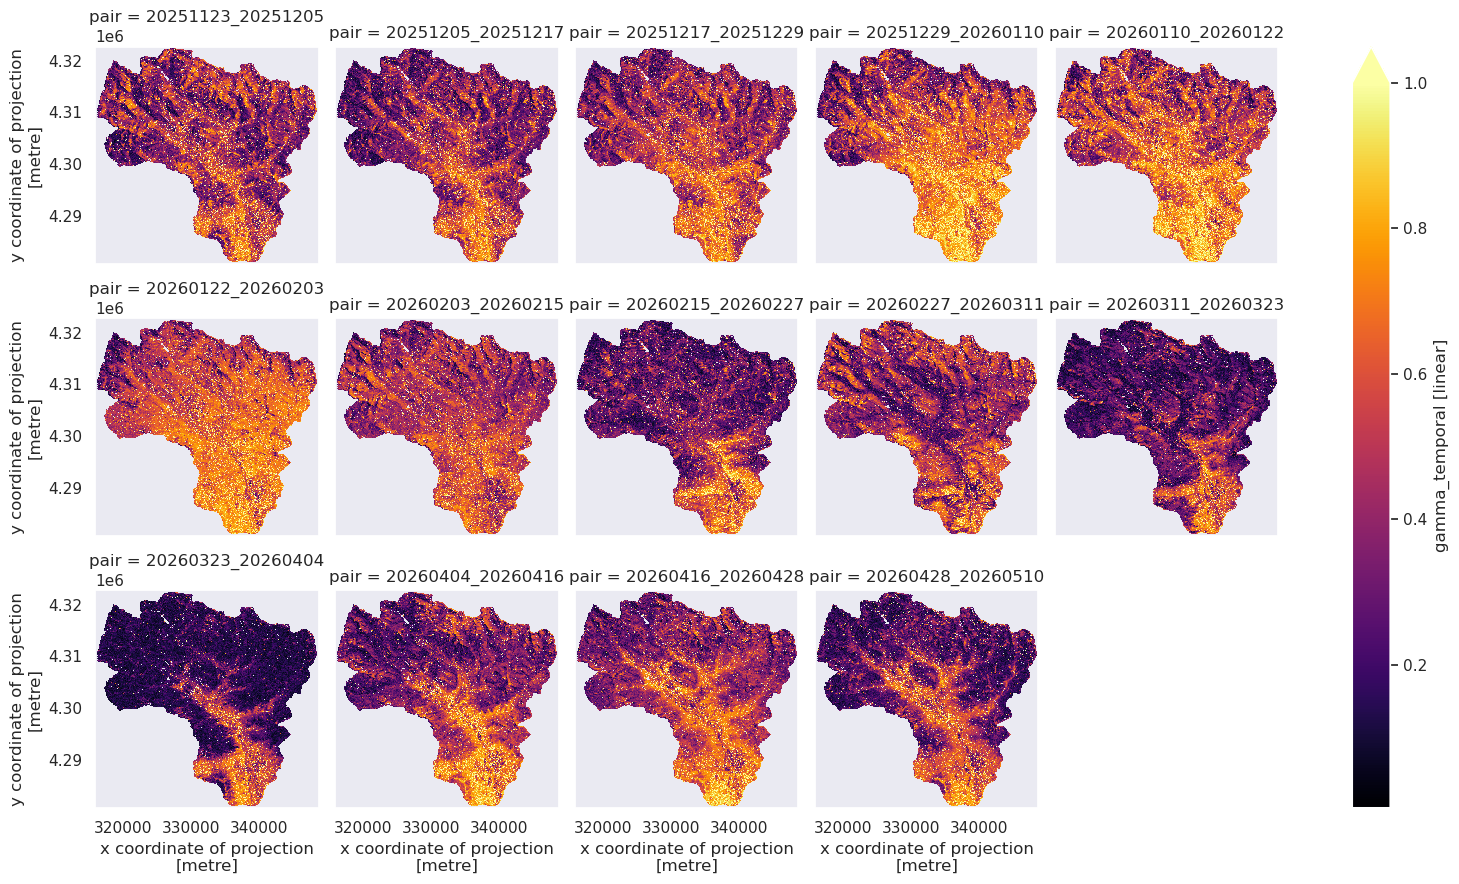

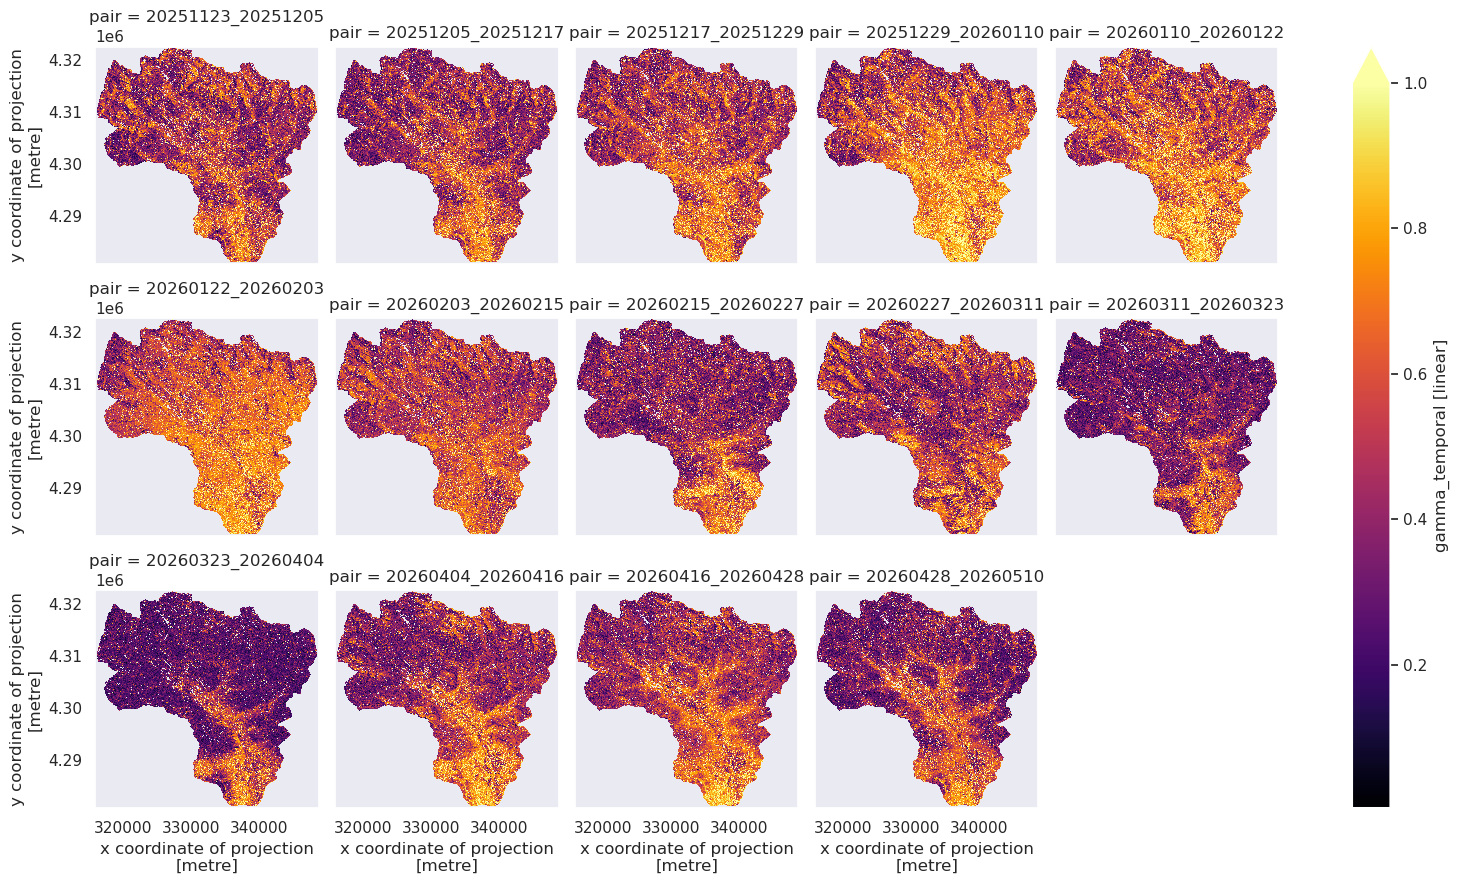

In [35]:
nisar_80m['gamma_temporal'].plot(col='pair', col_wrap=5, cmap='inferno', vmax=1)
nisar_20m['gamma_temporal'].plot(col='pair', col_wrap=5, cmap='inferno', vmax=1)

In [33]:
nisar_80m

<xarray.Dataset> Size: 40MB
Dimensions:         (y: 524, x: 410, band: 1, pair: 14)
Coordinates:
  * y               (y) float64 4kB 4.323e+06 4.323e+06 ... 4.281e+06 4.281e+06
  * x               (x) float64 3kB 3.16e+05 3.16e+05 ... 3.486e+05 3.487e+05
  * band            (band) int64 8B 1
  * pair            (pair) <U17 952B '20251123_20251205' ... '20260428_20260510'
    end             (pair) datetime64[ns] 112B dask.array<chunksize=(14,), meta=np.ndarray>
    start           (pair) datetime64[ns] 112B dask.array<chunksize=(14,), meta=np.ndarray>
    spatial_ref     int64 8B 0
Data variables:
    canopy_2019     (y, x, band) float32 859kB dask.array<chunksize=(262, 205, 1), meta=np.ndarray>
    coherence       (pair, y, x, band) float32 12MB dask.array<chunksize=(4, 131, 205, 1), meta=np.ndarray>
    cover_2019      (y, x, band) float64 2MB dask.array<chunksize=(524, 410, 1), meta=np.ndarray>
    elevation       (y, x, band) float32 859kB dask.array<chunksize=(262, 205, 1), meta=np.ndarray>
    gamma_temporal  (pair, y, x, band) float64 24MB dask.array<chunksize=(4, 131, 205, 1), meta=np.ndarray>

In [34]:
nisar_20m

<xarray.Dataset> Size: 630MB
Dimensions:         (y: 2091, x: 1638, band: 1, pair: 14)
Coordinates:
  * y               (y) float64 17kB 4.323e+06 4.323e+06 ... 4.281e+06 4.281e+06
  * x               (x) float64 13kB 3.16e+05 3.16e+05 ... 3.487e+05 3.487e+05
  * band            (band) int64 8B 1
  * pair            (pair) <U17 952B '20251123_20251205' ... '20260428_20260510'
    end             (pair) datetime64[ns] 112B dask.array<chunksize=(14,), meta=np.ndarray>
    start           (pair) datetime64[ns] 112B dask.array<chunksize=(14,), meta=np.ndarray>
    spatial_ref     int64 8B 0
Data variables:
    canopy_2019     (y, x, band) float32 14MB dask.array<chunksize=(262, 410, 1), meta=np.ndarray>
    coherence       (pair, y, x, band) float32 192MB dask.array<chunksize=(2, 523, 410, 1), meta=np.ndarray>
    cover_2019      (y, x, band) float64 27MB dask.array<chunksize=(523, 819, 1), meta=np.ndarray>
    elevation       (y, x, band) float32 14MB dask.array<chunksize=(262, 410, 1), meta=np.ndarray>
    gamma_temporal  (pair, y, x, band) float64 384MB dask.array<chunksize=(2, 523, 410, 1), meta=np.ndarray>

Save the zarrs. 

In [38]:
snr.to_zarr(data_dir + 'nisar/zarrs/snr.zarr', mode="w")
# gamma_thermal.to_dataset(name='gamma_thermal').to_zarr(data_dir + 'nisar/zarrs/gamma_thermal.zarr', mode="w")
# gamma_spatial.to_dataset(name='gamma_spatial').to_zarr(data_dir + 'nisar/zarrs/gamma_spatial.zarr', mode="w")
nisar_20m.to_zarr(data_dir + 'nisar/zarrs/coherence_20m.zarr', mode="w")
nisar_80m.to_zarr(data_dir + 'nisar/zarrs/coherence_80m.zarr', mode="w")

/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=91, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/bsuhome/julialober/miniforge3/